# Raman Spectroscopy Data Analysis: Combination of Two Amino Acids

This notebook demonstrates the numerical analysis for two amino acids combinations.

## Dataset Overview
- **Source**: Raman spectroscopy measurements of amino acid powders
- **Laser**: 532nm
- **Samples**: Background (blank slide) + 19 amino acids
- **Format**: Tab-separated text files with wavenumber and intensity data

## Import required tools and functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from spectra import SpectraCollection, Spectrum
from spectra import read_spectrum_file, read_simple_spectrum
from spectra import subtract_baseline_arpls, subtract_baseline_als, PreprocessingPipeline, normalize_minmax, calculate_snr, Spectrum
from spectra import calculate_snr, export_to_npz

# Set random seed for reproducible example selection
np.random.seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

def get_txt_filepath(name, root='./data/batch1'):
    if '+' in name:
        folder = Path(root) / name
    else:
        amino_acid = f'{name[0].upper()}{name[1:]}' if name == 'glycine' else f'L-{name[0].upper()}{name[1:]}'
        folder = Path(root) / amino_acid
    filenames = list(folder.glob(f'*.txt'))

    collection_path = None
    test_spectrum_path = None
    if len(filenames) > 0:
        for filename in filenames:
            if 'test' in filename.stem:
                test_spectrum_path = filename
            if 'power' in filename.stem:
                collection_path = filename
    return collection_path, test_spectrum_path

def get_fingerprint(collection, threshold=50):
    snr = calculate_snr(collection)
    intensities = collection.to_intensity_matrix()
    mean_intensity = intensities[snr>threshold, :].mean(axis=0)
    fingerprint = Spectrum(np.stack((collection.wavelengths, mean_intensity), axis=1))
    return fingerprint

def plot_colletion_and_test_spectrum(collection, test_spectrum, title=' Raman Spectroscopy Data'):
    # visualise raw data
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))
    
    if collection:
       mean_intensities = collection.to_intensity_matrix().mean(axis=0)
       ax1.plot(collection.wavelengths, mean_intensities,
               'k-', linewidth=1.5, label='Fingerprint')
        
    if test_spectrum:
        ax1.plot(test_spectrum.wavelengths, test_spectrum.intensities,
                 'g-', linewidth=1.5, alpha=1, label='Test Spectrum')
        
    ax1.set_xlabel('Wavenumber (cm⁻¹)')
    ax1.set_ylabel('Intensity (a.u.)')
    ax1.set_title(title)
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Data Structure

The spectra package handles two file formats:

### 1. Simple Format (2 columns)
Single spectrum per file with `#Wave` and `#Intensity` columns:
```
#Wave        #Intensity
1925.662109  217.207626
1924.119141  189.444244
...
```

### 2. Mapped Format (4 columns)
Multiple spectra per file with spatial coordinates `#X`, `#Y`, `#Wave`, `#Intensity`:
```
#X            #Y            #Wave        #Intensity
-10007.539247 -13426.202300 1925.662109  129.018066
-10007.539247 -13426.202300 1924.119141  130.651199
...
```

New spectra are detected when the X coordinate changes.

### Key Properties
- **Wavenumber range**: ~157 to ~1925 cm⁻¹
- **Points per spectrum**: 1023
- **Wavelength order**: Stored in ascending order (low to high)

In [2]:
def process_pipeline(name, save_npz = True, save_dir= Path('./data/monopeptide')):
    save_dir = save_dir / name
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # IO: read raw txt files for Raman Sepectroscopy Data
    collection_path, test_spectrum_path = get_txt_filepath(name, root='./data/batch2')
    if collection_path:
        collection = read_spectrum_file(collection_path)
        print(f"{name}: {len(collection)} spectra loaded")
        if save_npz:
            export_to_npz(collection, save_dir / 'raw_data.npz')
            print(f"Saved spectra data at {save_dir / 'raw_data.npz'}")        
    else:
        print(f"{name}: Missing spectra")
    
    if test_spectrum_path:
        test_collection = read_spectrum_file(test_spectrum_path)
        print(f"Test spectrum is loaded for {name}")
        if save_npz:
            export_to_npz(test_collection, save_dir / 'raw_test_spectrum.npz')
            print(f"Saved test spectrum data at {save_dir / 'raw_test_spectrum.npz'}") 
        test_spectrum = test_collection[0]
    else:
        test_spectrum = None
        print(f" Missing test spectrum for {name}")
    
    # Plot the raw data
    plot_colletion_and_test_spectrum(collection, test_spectrum, title=' Raman Spectroscopy Data (RAW)')
    
    # Preprocessing: Baseline correction, Noise removal and min-max normalisaiton
    collection = (PreprocessingPipeline(collection)
        .normalize()                                   # Min-max normalization to [0,1]
        .subtract_baseline(lam=1e2, method='als')      # Simple Asymmetric Least Squares baseline correction.
        .smooth(window_length=11, polyorder=3)         # Savitzky-Golay filter
        .normalize()                                   # Min-max normalization to [0,1]
        .result()
        )
    if save_npz:
        export_to_npz(collection, save_dir / 'data.npz')
        print(f"Saved preprocessed spectra data at {save_dir / 'data.npz'}") 

    if test_spectrum:
        test_spectrum = (PreprocessingPipeline(test_spectrum)
            .normalize()                                   # Min-max normalization to [0,1]
            .subtract_baseline(lam=1e2, method='als')      # Simple Asymmetric Least Squares baseline correction.
            .smooth(window_length=11, polyorder=3)         # Savitzky-Golay filter
            .normalize()                                   # Min-max normalization to [0,1]
            .result()
            )
        
        if save_npz:
            test_collection = SpectraCollection([test_spectrum], source_file=test_spectrum_path)
            export_to_npz(test_collection, save_dir / 'test_spectrum.npz')
            print(f"Saved preprocessed test spectrum data at {save_dir / 'test_spectrum.npz'}")
    
    # Plot the preprocessed data
    plot_colletion_and_test_spectrum(collection, test_spectrum, title='Raman Spectroscopy Data (preprocessed)')
    
    # Fingerprint Generation: filter spectra data based on SNR and select top 100 results for averaging
    fingerprint = get_fingerprint(collection, threshold=50)
    fingerprint_collection = SpectraCollection([fingerprint], source_file=collection_path)
    if save_npz:
        export_to_npz(fingerprint_collection, save_dir / 'fingerprint.npz')
    
    plot_colletion_and_test_spectrum(fingerprint_collection, test_spectrum, title='Raman Spectroscopy Data (SNR>50)')

# Combos with Two Amino Acids

## A+D

A+D: 1292 spectra loaded
Saved spectra data at data\combos2\A+D\raw_data.npz
Test spectrum is loaded for A+D
Saved test spectrum data at data\combos2\A+D\raw_test_spectrum.npz


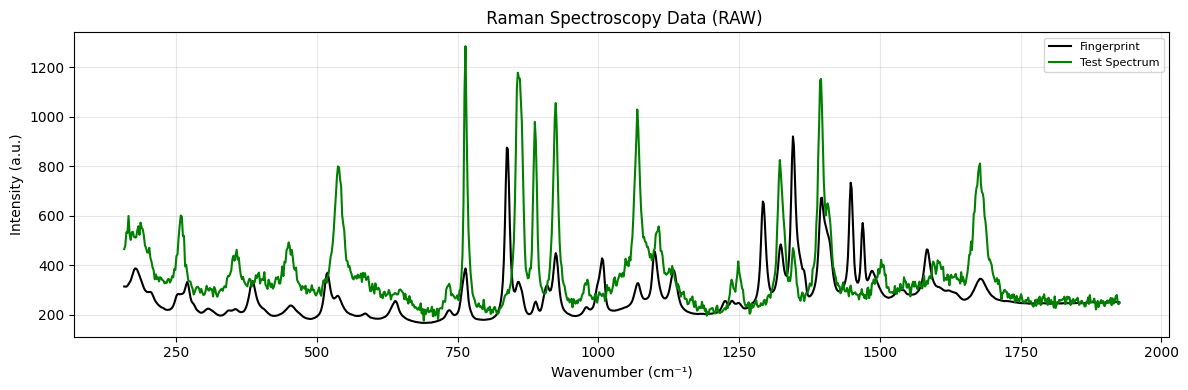

Saved preprocessed spectra data at data\combos2\A+D\data.npz
Saved preprocessed test spectrum data at data\combos2\A+D\test_spectrum.npz


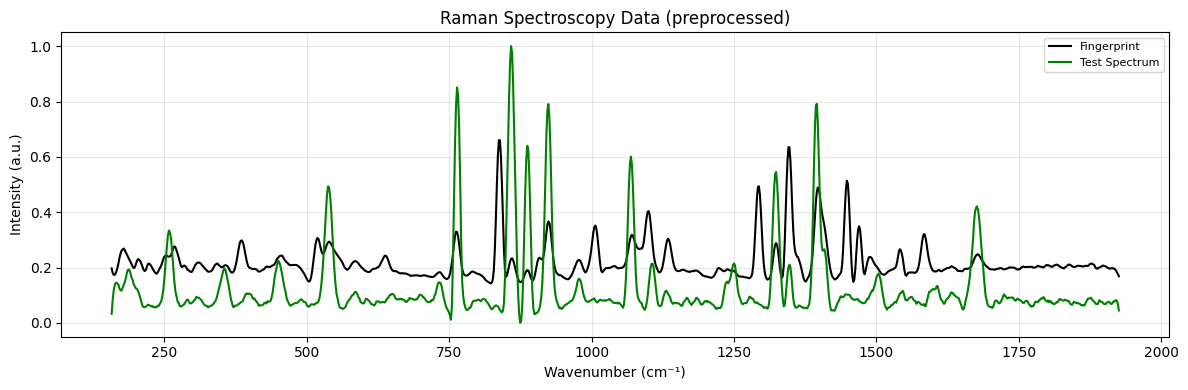

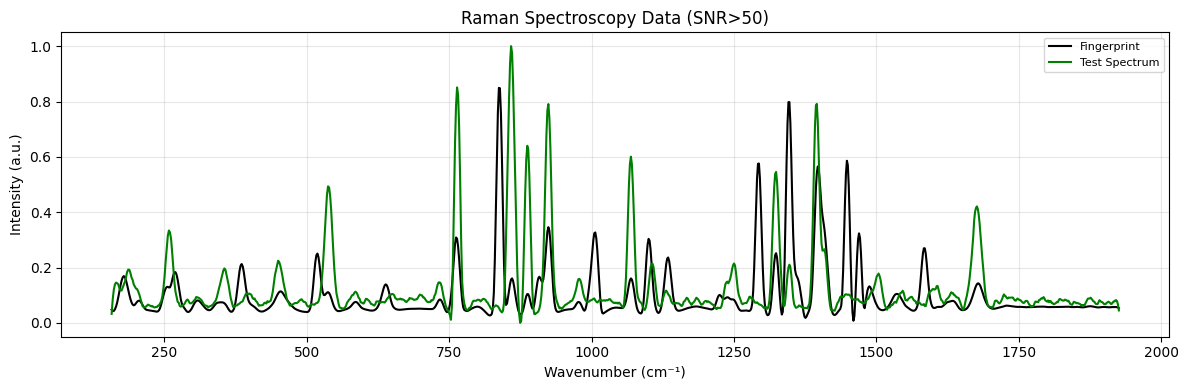

In [4]:
name = 'A+D'
process_pipeline(name, save_dir = Path('./data/combos2'))

## A+F

A+F: 1271 spectra loaded
Saved spectra data at data\combos2\A+F\raw_data.npz
Test spectrum is loaded for A+F
Saved test spectrum data at data\combos2\A+F\raw_test_spectrum.npz


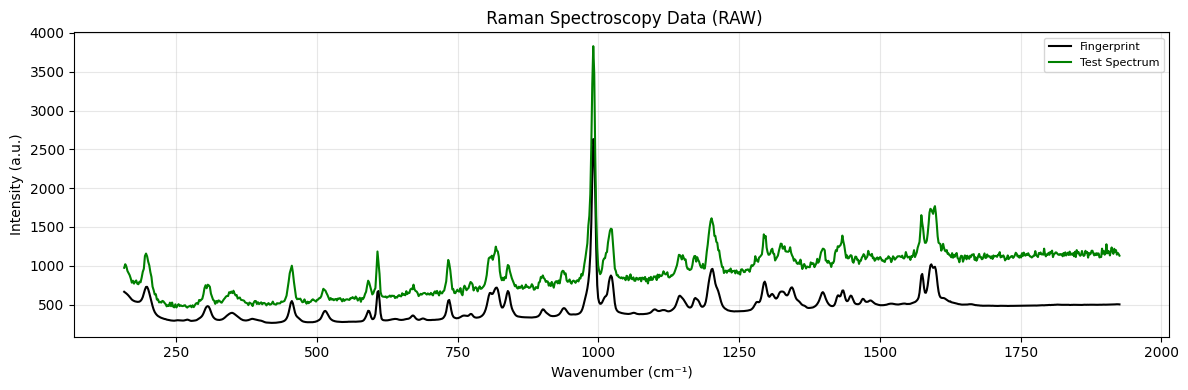

Saved preprocessed spectra data at data\combos2\A+F\data.npz
Saved preprocessed test spectrum data at data\combos2\A+F\test_spectrum.npz


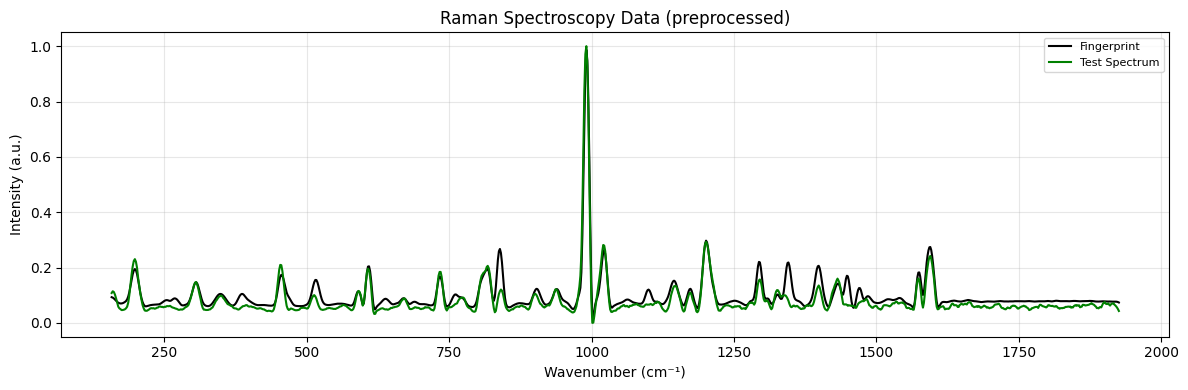

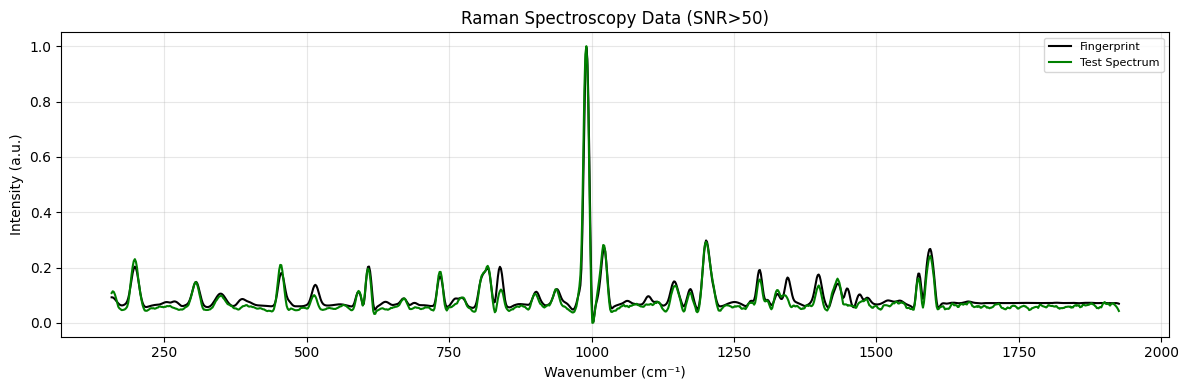

In [5]:
name = 'A+F'
process_pipeline(name, save_dir = Path('./data/combos2'))

## A+G

A+G: 1296 spectra loaded
Saved spectra data at data\combos2\A+G\raw_data.npz
Test spectrum is loaded for A+G
Saved test spectrum data at data\combos2\A+G\raw_test_spectrum.npz


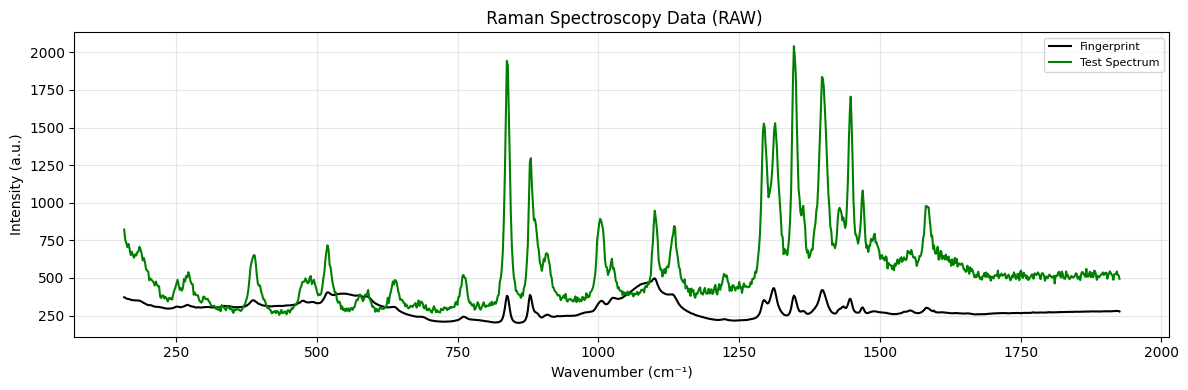

Saved preprocessed spectra data at data\combos2\A+G\data.npz
Saved preprocessed test spectrum data at data\combos2\A+G\test_spectrum.npz


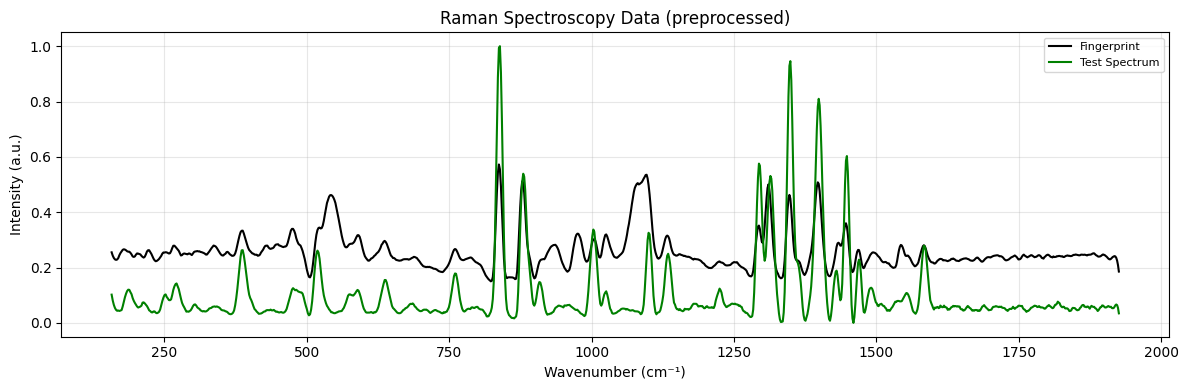

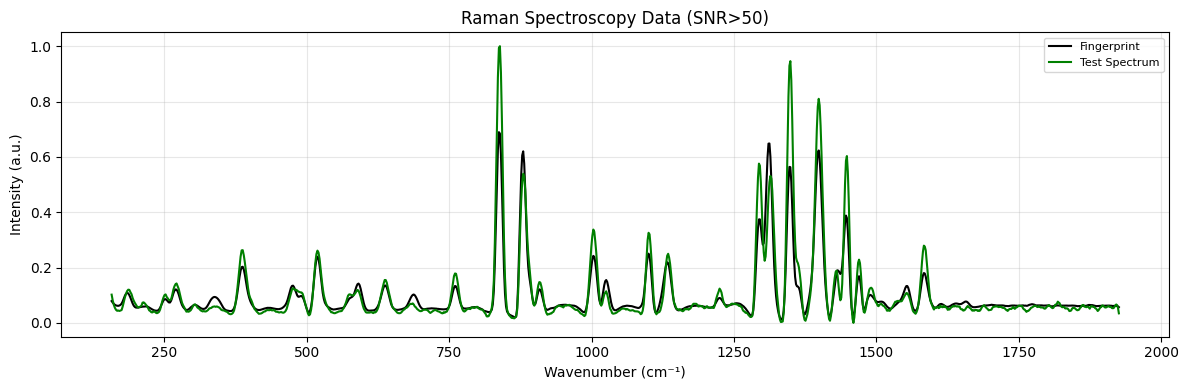

In [6]:
name = 'A+G'
process_pipeline(name, save_dir = Path('./data/combos2'))

## A+S

A+S: 1200 spectra loaded
Saved spectra data at data\combos2\A+S\raw_data.npz
Test spectrum is loaded for A+S
Saved test spectrum data at data\combos2\A+S\raw_test_spectrum.npz


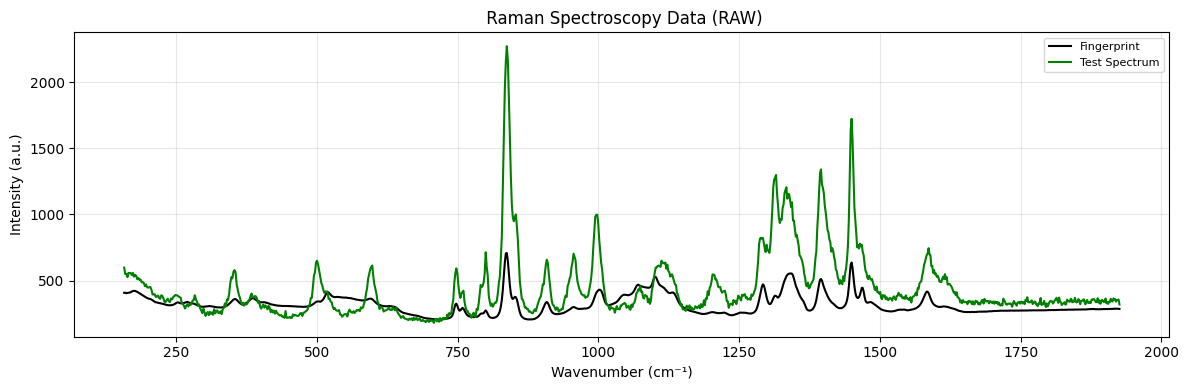

Saved preprocessed spectra data at data\combos2\A+S\data.npz
Saved preprocessed test spectrum data at data\combos2\A+S\test_spectrum.npz


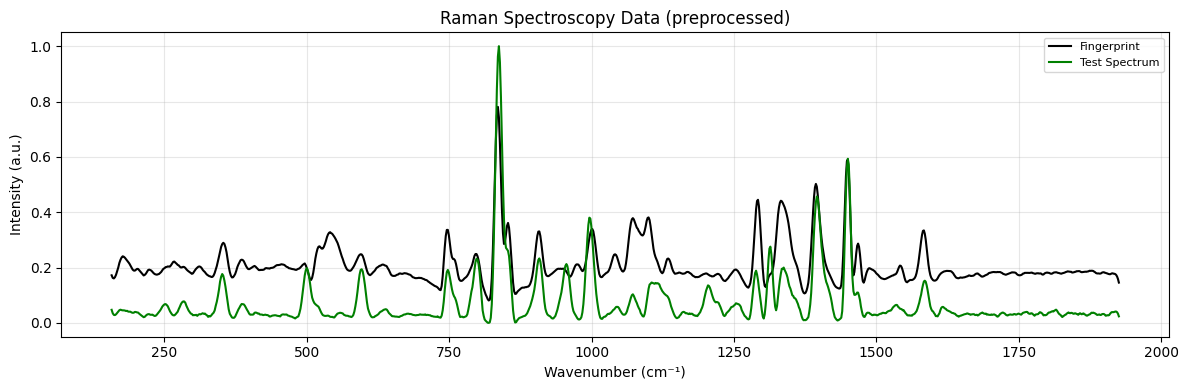

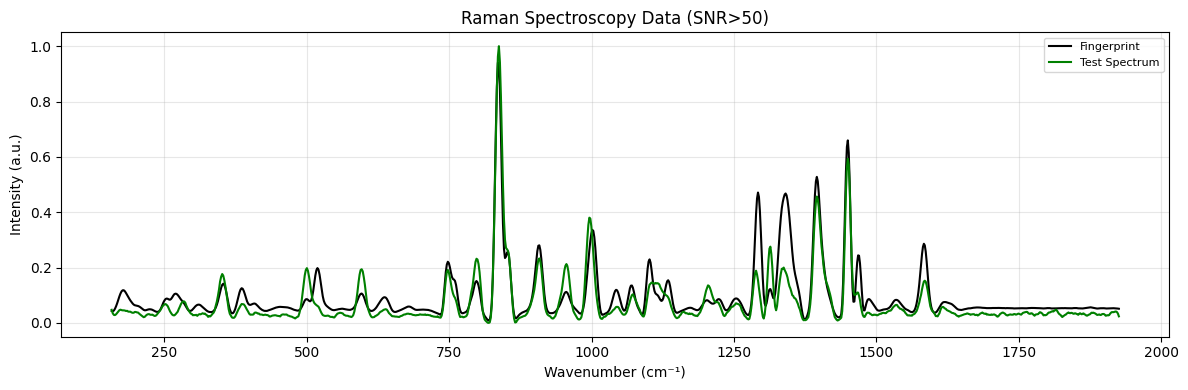

In [7]:
name = 'A+S'
process_pipeline(name, save_dir = Path('./data/combos2'))

## D+F

D+F: 1204 spectra loaded
Saved spectra data at data\combos2\D+F\raw_data.npz
Test spectrum is loaded for D+F
Saved test spectrum data at data\combos2\D+F\raw_test_spectrum.npz


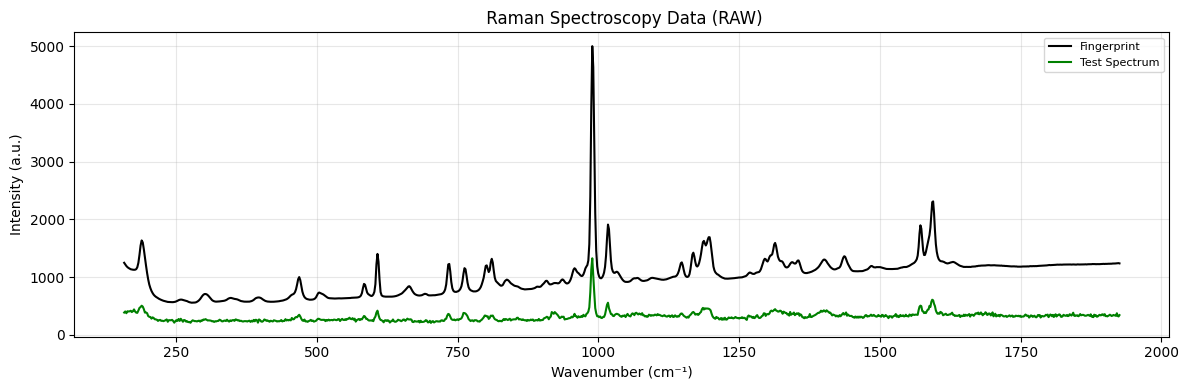

Saved preprocessed spectra data at data\combos2\D+F\data.npz
Saved preprocessed test spectrum data at data\combos2\D+F\test_spectrum.npz


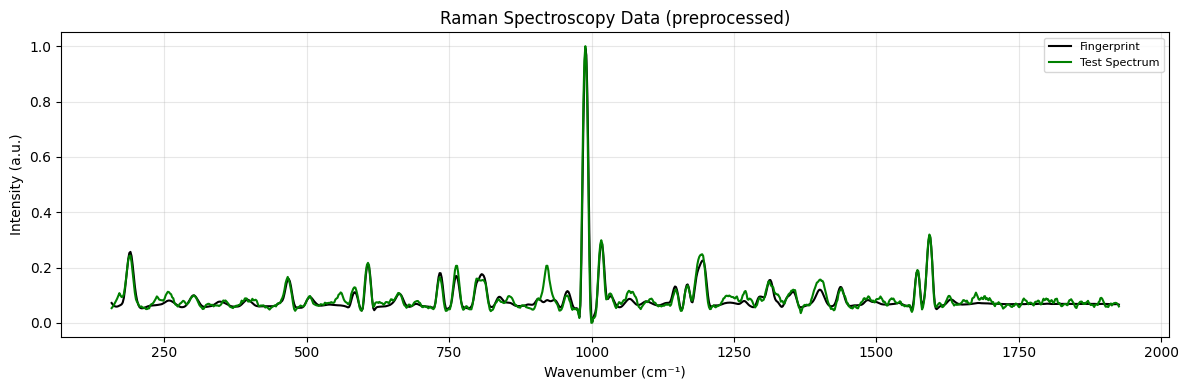

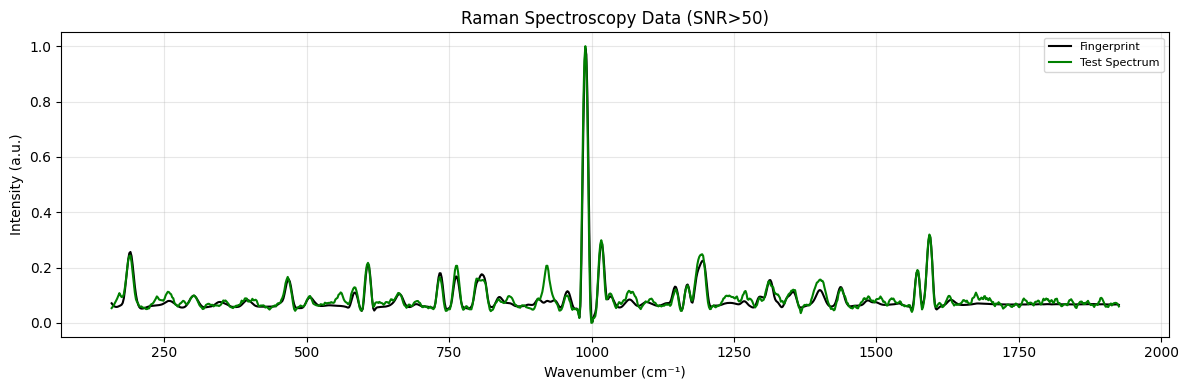

In [8]:
name = 'D+F'
process_pipeline(name, save_dir = Path('./data/combos2'))

## D+G

D+G: 1260 spectra loaded
Saved spectra data at data\combos2\D+G\raw_data.npz
Test spectrum is loaded for D+G
Saved test spectrum data at data\combos2\D+G\raw_test_spectrum.npz


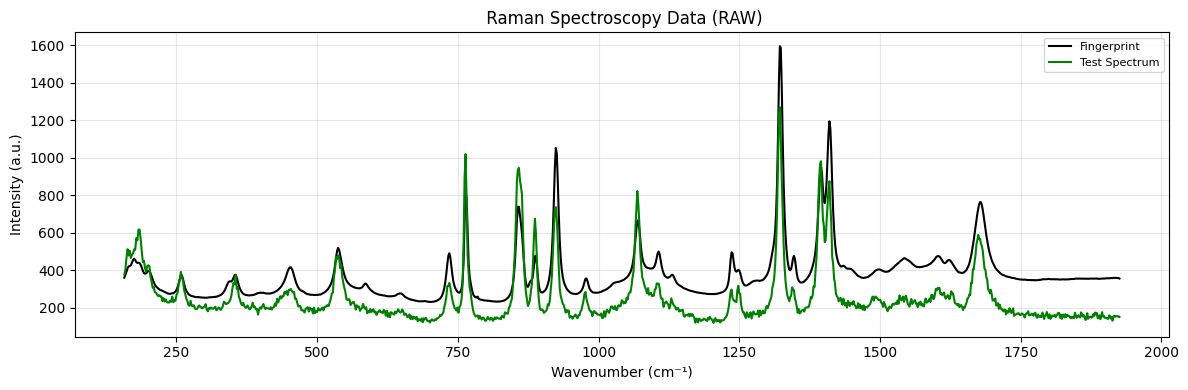

Saved preprocessed spectra data at data\combos2\D+G\data.npz
Saved preprocessed test spectrum data at data\combos2\D+G\test_spectrum.npz


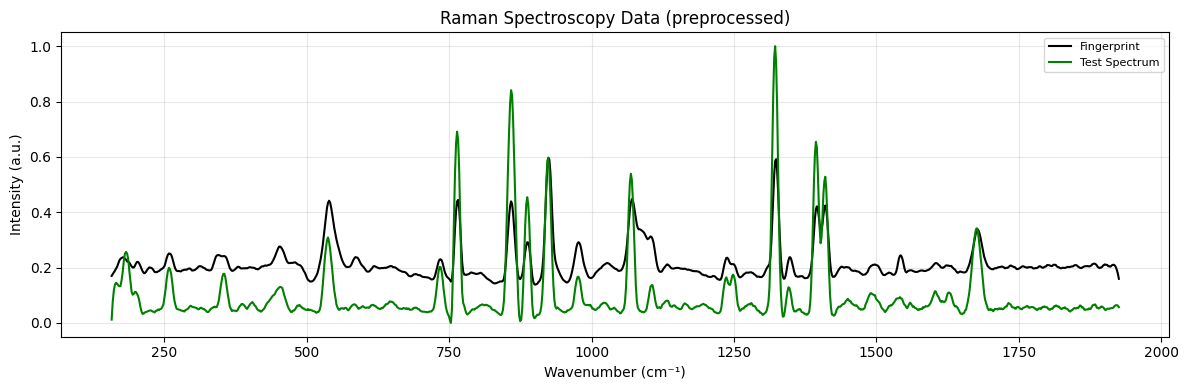

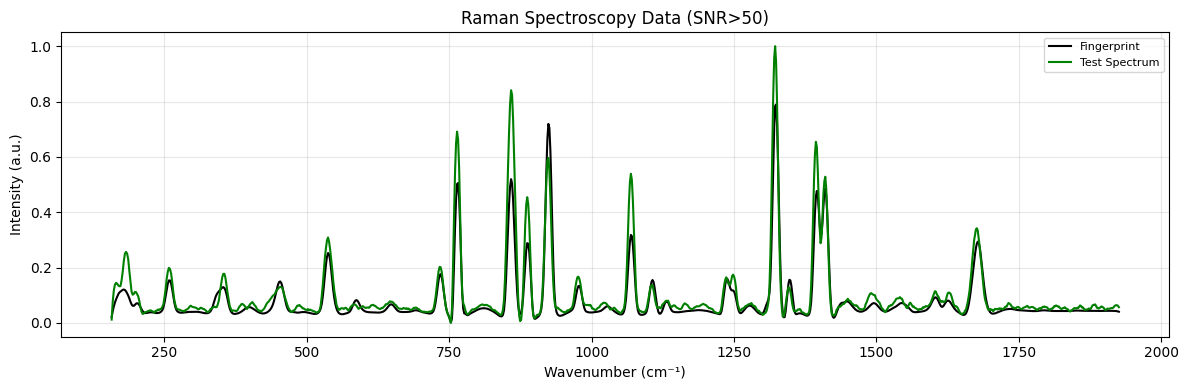

In [9]:
name = 'D+G'
process_pipeline(name, save_dir = Path('./data/combos2'))

## D+S

D+S: 1184 spectra loaded
Saved spectra data at data\combos2\D+S\raw_data.npz
 Missing test spectrum for D+S


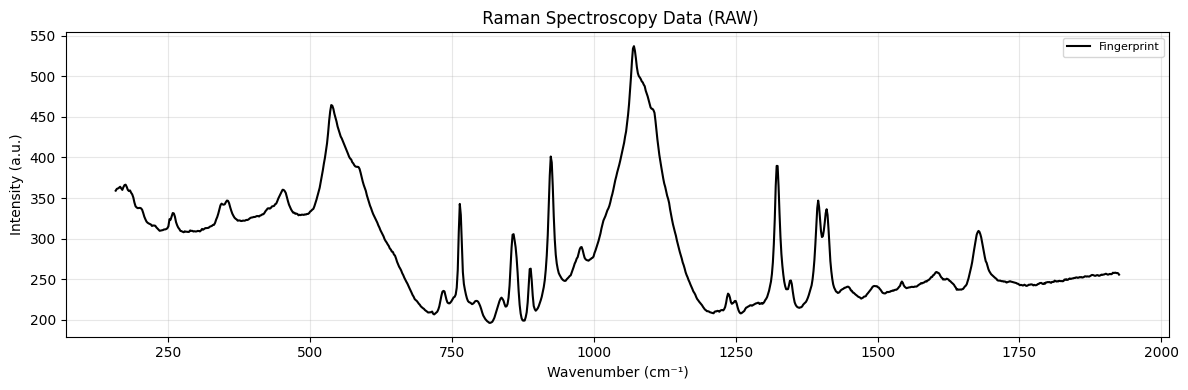

Saved preprocessed spectra data at data\combos2\D+S\data.npz


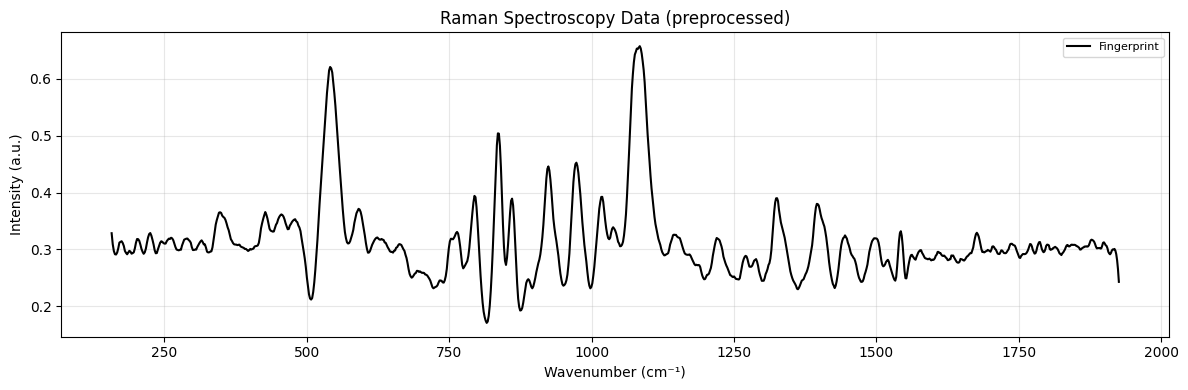

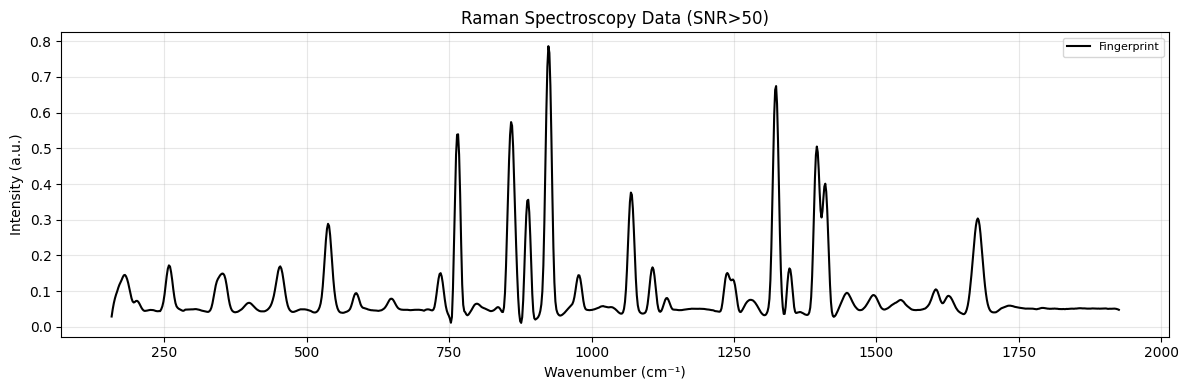

In [10]:
name = 'D+S'
process_pipeline(name, save_dir = Path('./data/combos2'))

## F+G

F+G: 1276 spectra loaded
Saved spectra data at data\combos2\F+G\raw_data.npz
Test spectrum is loaded for F+G
Saved test spectrum data at data\combos2\F+G\raw_test_spectrum.npz


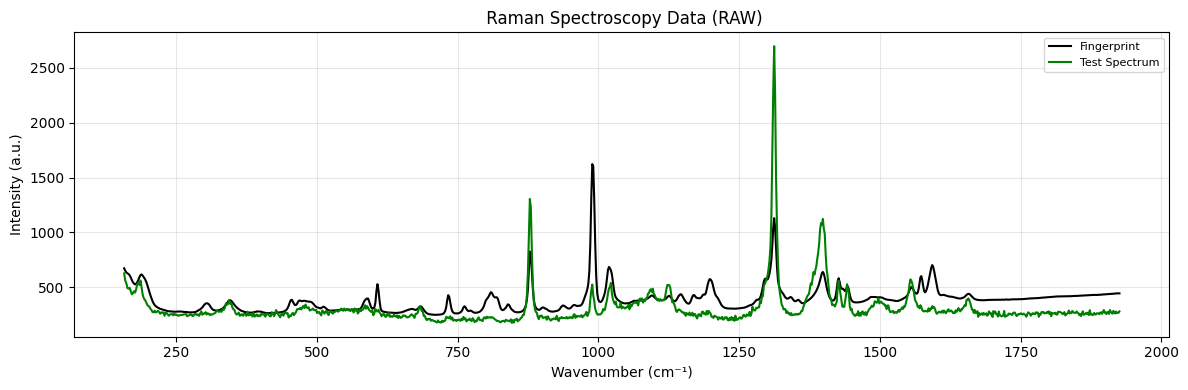

Saved preprocessed spectra data at data\combos2\F+G\data.npz
Saved preprocessed test spectrum data at data\combos2\F+G\test_spectrum.npz


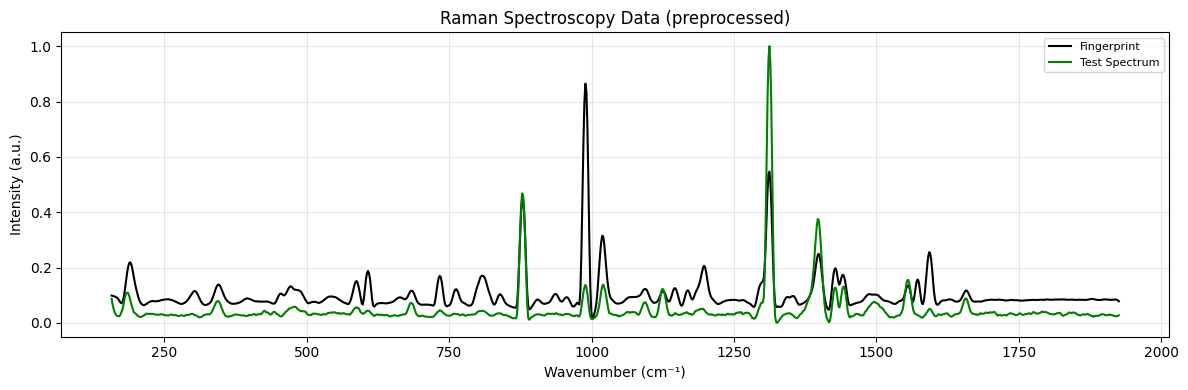

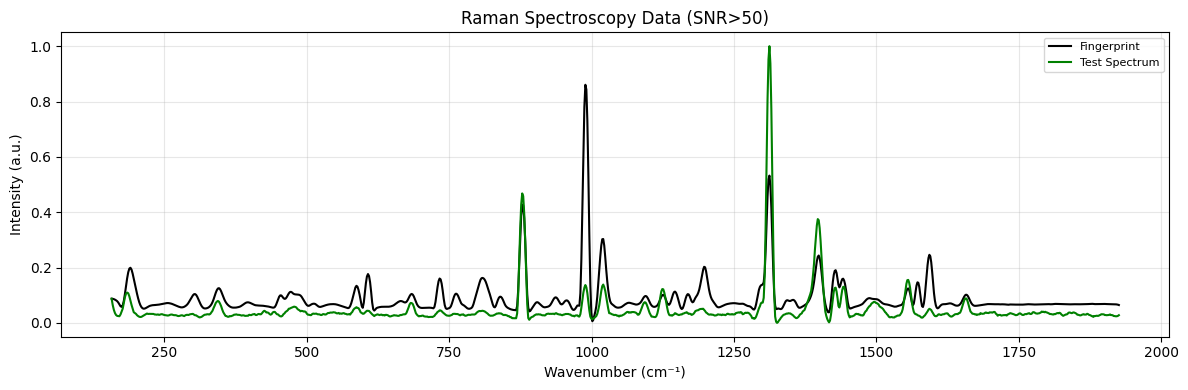

In [11]:
name = 'F+G'
process_pipeline(name, save_dir = Path('./data/combos2'))

# Single Amino Acid Detection from Combos
For each combos of two amino acids, assess single amino acid detection algorithm.

In [7]:
from spectra.models import convert_amino_acid, AMINO_ACID_THREE_LETTER
from spectra.data.spectraio import load_from_npz
from spectra import calculate_snr
from spectra.models import SpectralPredictor
# Load the model
save_path = 'checkpoints/spectral_transformer_final.pt'
predictor = SpectralPredictor.load(save_path)
print("Model loaded successfully!")
label_names=predictor.label_mapping

def plot_fingerprints(*spectra, title='Combos Experiment'):
    """Plot arbitrary number of fingerprints.

    Args:
        *spectra: Variable number of (fingerprint, label) tuples.
        title: Plot title (keyword argument only).

    Example:
        plot_fingerprints((fg0, 'A+D'), (fg1, 'alanine'), (fg2, 'aspartic acid'), title='Combos')
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))

    colors = plt.cm.tab10.colors
    for i, (fg, label) in enumerate(spectra):
        if fg:
            color = colors[i % len(colors)]
            alpha = 1.0 if i == 0 else 0.6
            ax1.plot(fg.wavelengths, fg.intensities,
                     '-', color=color, linewidth=2, alpha=alpha, label=label)

    ax1.set_xlabel('Wavenumber (cm⁻¹)')
    ax1.set_ylabel('Intensity (a.u.)')
    ax1.set_title(title)
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Model loaded successfully!


C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [8]:
# define a pipeline
def process_mixed_amino_acids(name, snr_threshold=30):
    aa1 = convert_amino_acid(name.split('+')[0], "full")
    cls1 = None
    for key, value in label_names.items():
        if aa1 == value:
            cls1 = key
            break;
    aa2 = convert_amino_acid(name.split('+')[1], 'full')
    cls2 = None
    for key, value in label_names.items():
        if aa2 == value:
            cls2 = key
            break;
    print(f'{name}\n{aa1}({cls1})\t{aa2}({cls2})\n')
    
    # read fingerprints
    fg1 = load_from_npz(Path('./data/monopeptide/') / aa1 / 'fingerprint.npz')[0]
    fg2 = load_from_npz(Path('./data/monopeptide/') / aa2 / 'fingerprint.npz')[0]
    
    # read combos data
    collection = load_from_npz(Path('./data/combos2/') / name / 'data.npz')
    snr_values = calculate_snr(collection)
    
    idx_data = np.where(snr_values>snr_threshold)[0]
    
    print('Summary:\n')
    print(f'Number of Spectra: {len(collection)}')
    print(f'Number of Noisy Spectra (SNR < {snr_threshold}): {len(collection)-len(idx_data)}')
    print(f'Number of Clean Spectra (SNR >= {snr_threshold}): {len(idx_data)}')
    
    # classify samples
    results = []
    for id0 in idx_data:
        fg0 = collection[id0]
        probs = predictor.predict_proba(fg0.intensities)[0]
        predicted_cls_ids = np.argsort(probs)[::-1][:2]
        result = {'id': id0,
                  'snr': snr_values[id0],
                  'probs': probs[predicted_cls_ids],
                  'labels': predicted_cls_ids
                 }
        results.append(result)

    # plot bins
    first_amino = []
    second_amino = []
    for r in results:
        first_amino.append(r['labels'][0])
        if r['probs'][1]>0.2:
            second_amino.append(r['labels'][1])
    counts1 = np.bincount(first_amino, minlength=19)
    counts2 = np.bincount(second_amino, minlength=19)
    x = np.arange(19)
    plt.bar(x, counts1, label='First Likely Amino Acid')
    plt.bar(x, counts2, label='Second Likely Amino Acid')
    plt.xticks(x, [name.capitalize() for name in label_names.values()], rotation=90)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()

    # scenario 1 (most likely cls1)
    first_amino = np.array([r['labels'][0] for r in results])
    max_p = np.array([r['probs'][0] for r in results])
    
    filter = np.where(np.logical_and(first_amino == cls1, max_p > 0.7))[0]
    if len(filter)>0:
        id0 = results[filter[0]]['id']
        fg0 = collection[id0]
        
        # plot samples
        plot_fingerprints((fg0, name), (fg1, aa1), (fg2, aa2), title=f'Most likely {aa1.capitalize()}')
        print(label_names[results[filter[0]]['labels'][0]].capitalize(), results[filter[0]]['probs'][0])
        print(label_names[results[filter[0]]['labels'][1]].capitalize(), results[filter[0]]['probs'][1])
    
    # scenario 2 (most likely cls2)
    filter = np.where(np.logical_and(first_amino == cls2, max_p > 0.7))[0]
    if len(filter)>0:
        id0 = results[filter[0]]['id']
        fg0 = collection[id0]
        
        # plot samples
        plot_fingerprints((fg0, name), (fg1, aa1), (fg2, aa2), title=f'Most likely {aa2.capitalize()}')
        print(label_names[results[filter[0]]['labels'][0]].capitalize(), results[filter[0]]['probs'][0])
        print(label_names[results[filter[0]]['labels'][1]].capitalize(), results[filter[0]]['probs'][1])
    
    # scenario 3 (both class presents)
    filter = np.where(np.logical_and(max_p<0.5, max_p > 0.4))[0]
    if len(filter) > 0:
        id0 = results[filter[0]]['id']
        fg0 = collection[id0]
        
        # plot samples
        plot_fingerprints((fg0, name), (fg1, aa1), (fg2, aa2), title=f'Amino Acid Combos')
        print(label_names[results[filter[0]]['labels'][0]].capitalize(), results[filter[0]]['probs'][0])
        print(label_names[results[filter[0]]['labels'][1]].capitalize(), results[filter[0]]['probs'][1])
    return results

A+D
alanine(0)	aspartic acid(3)

Summary:

Number of Spectra: 1292
Number of Noisy Spectra (SNR < 50): 588
Number of Clean Spectra (SNR >= 50): 704


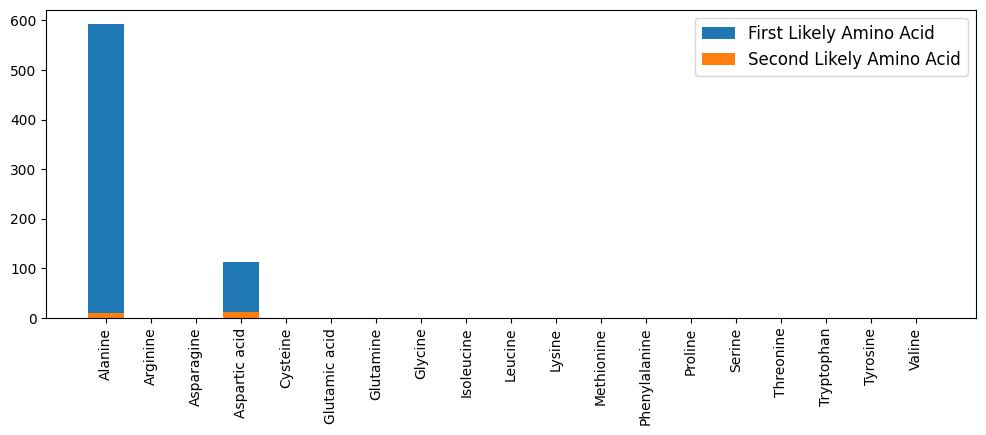

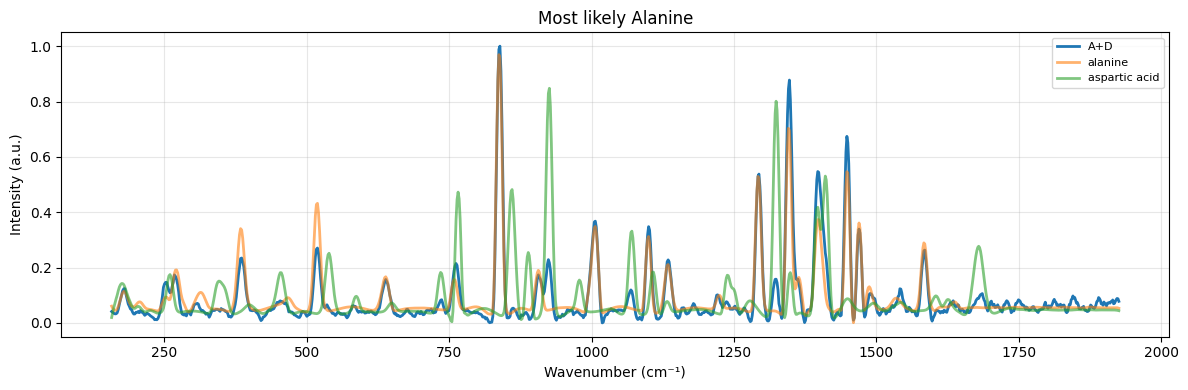

Alanine 0.9009011
Leucine 0.01617171


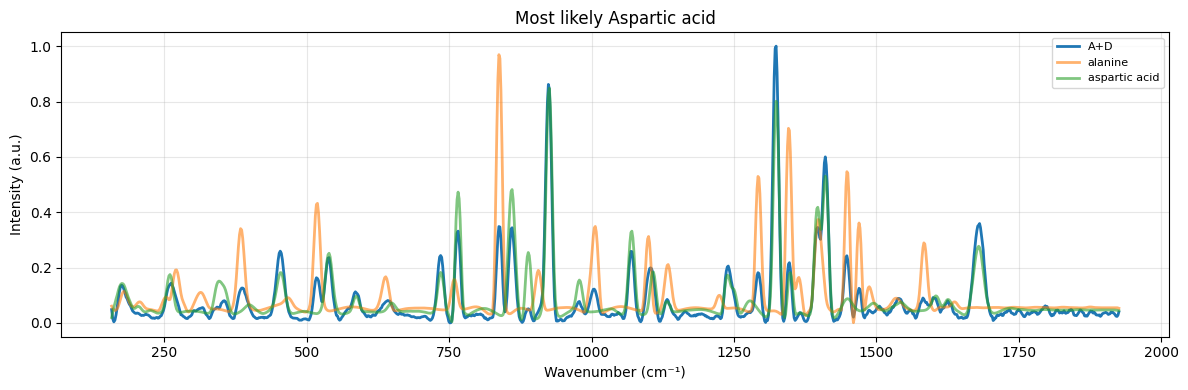

Aspartic acid 0.90697074
Asparagine 0.017206242


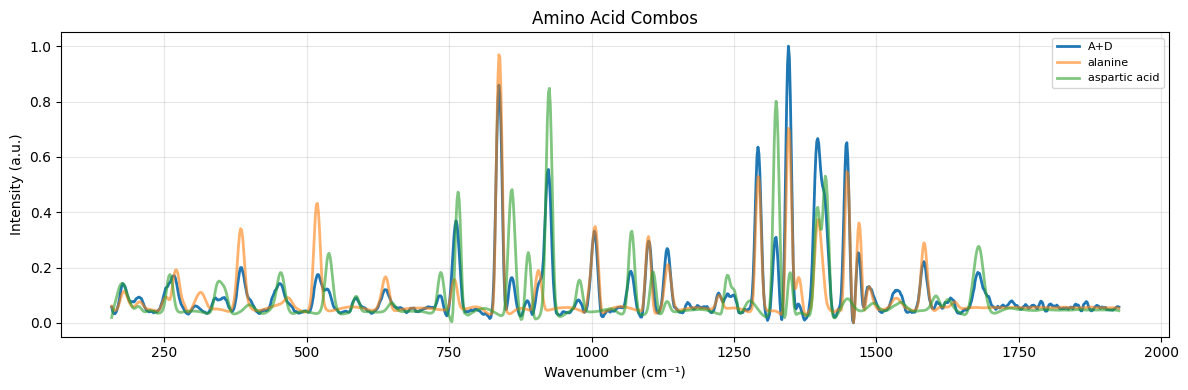

Alanine 0.48509297
Aspartic acid 0.15756965


In [9]:
name = 'A+D'
snr_threshold = 50
results = process_mixed_amino_acids(name, snr_threshold)

A+G
alanine(0)	glycine(7)

Summary:

Number of Spectra: 1296
Number of Noisy Spectra (SNR < 30): 972
Number of Clean Spectra (SNR >= 30): 324


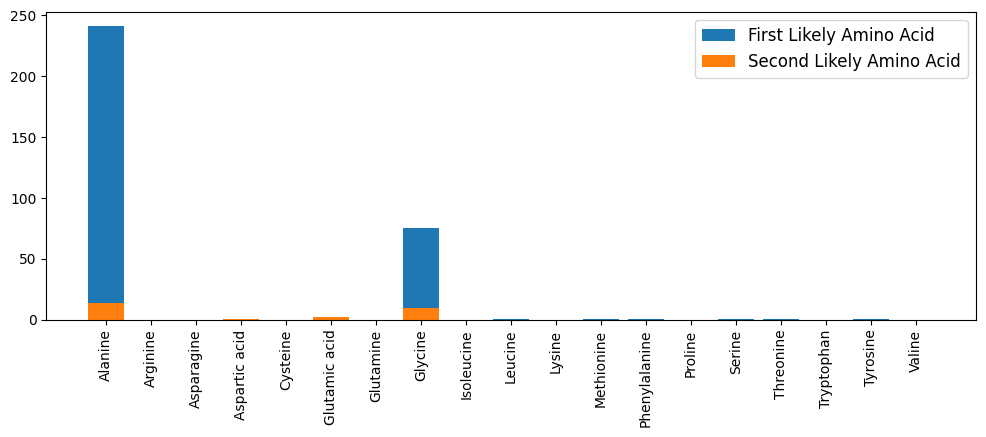

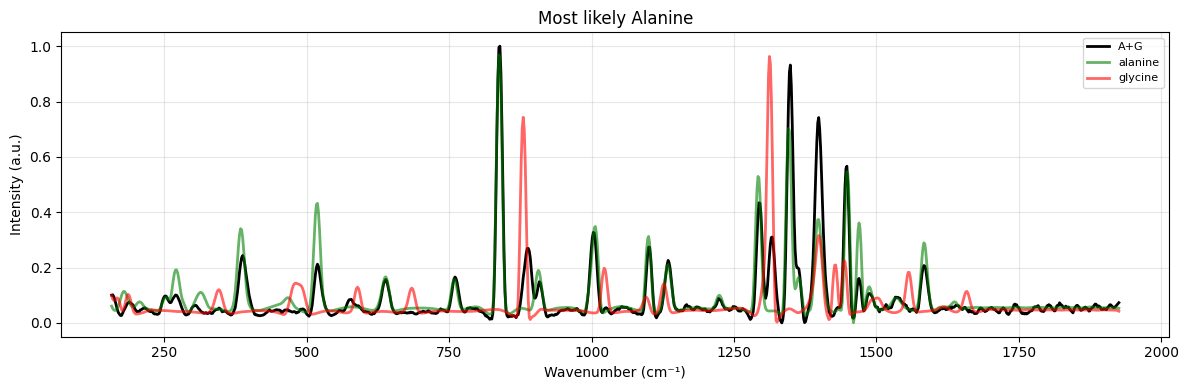

Alanine 0.85696906
Leucine 0.02919466


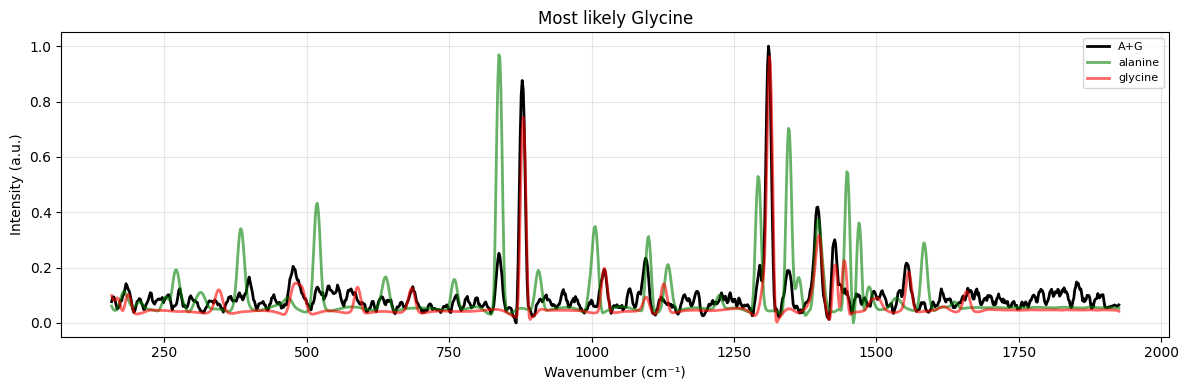

Glycine 0.7506284
Alanine 0.043285545


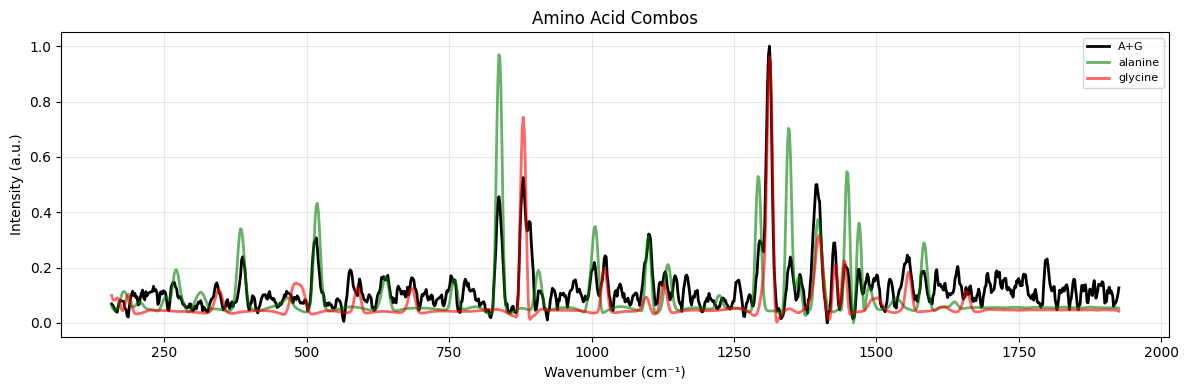

Alanine 0.41193673
Glycine 0.23238772


In [194]:
name = 'A+G'
snr_threshold = 30
results = process_mixed_amino_acids(name, snr_threshold=30)

A+S
alanine(0)	serine(14)

Summary:

Number of Spectra: 1200
Number of Noisy Spectra (SNR < 50): 723
Number of Clean Spectra (SNR >= 50): 477


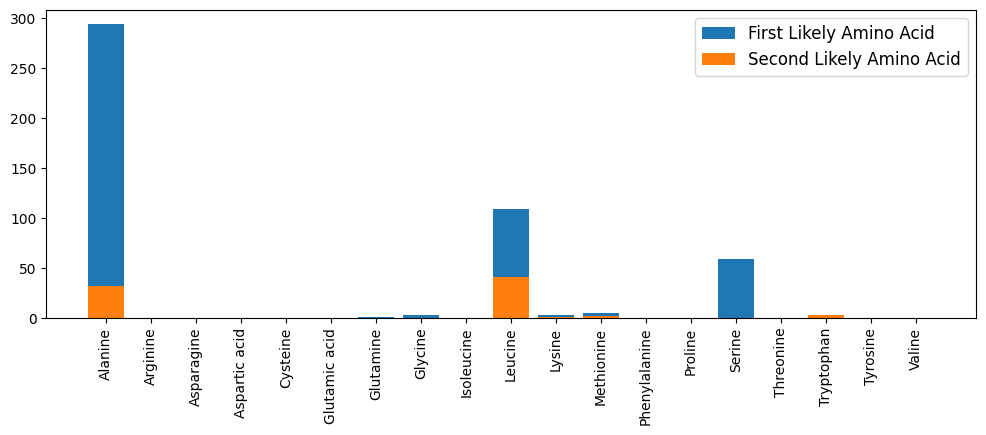

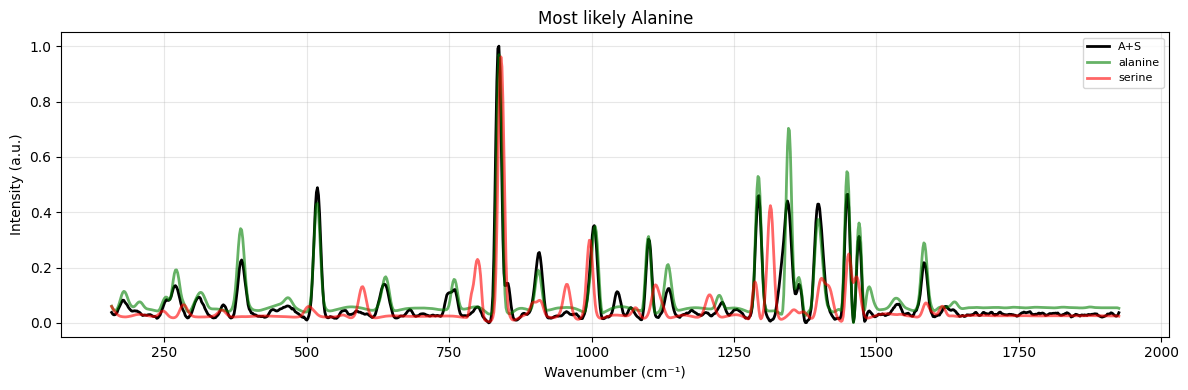

Alanine 0.84969455
Leucine 0.041393284


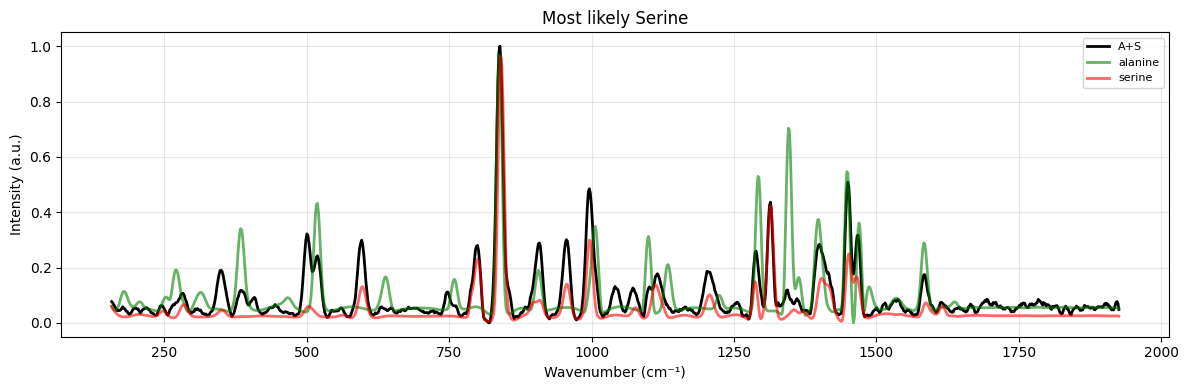

Serine 0.9214196
Lysine 0.007368004


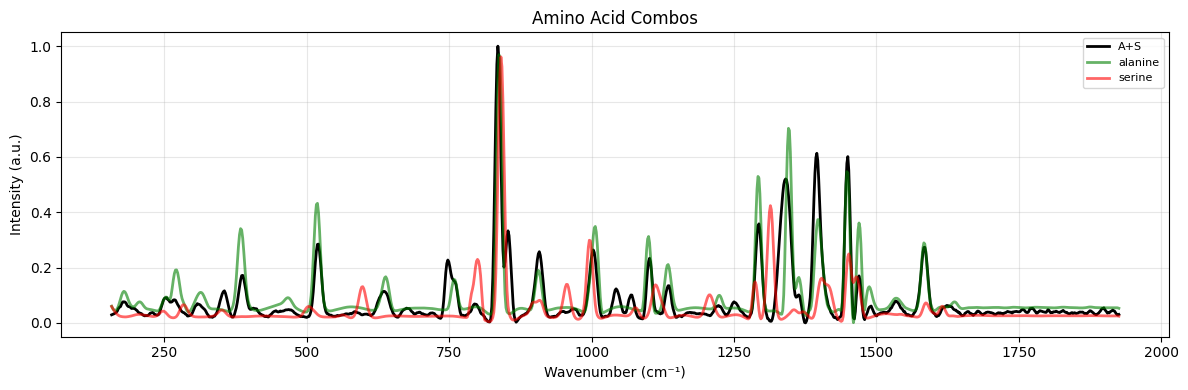

Alanine 0.46424726
Leucine 0.30606067


In [7]:
name = 'A+S'
snr_threshold = 50
results = process_mixed_amino_acids(name, snr_threshold)

D+F
aspartic acid(3)	phenylalanine(12)

Summary:

Number of Spectra: 1204
Number of Noisy Spectra (SNR < 30): 9
Number of Clean Spectra (SNR >= 30): 1195


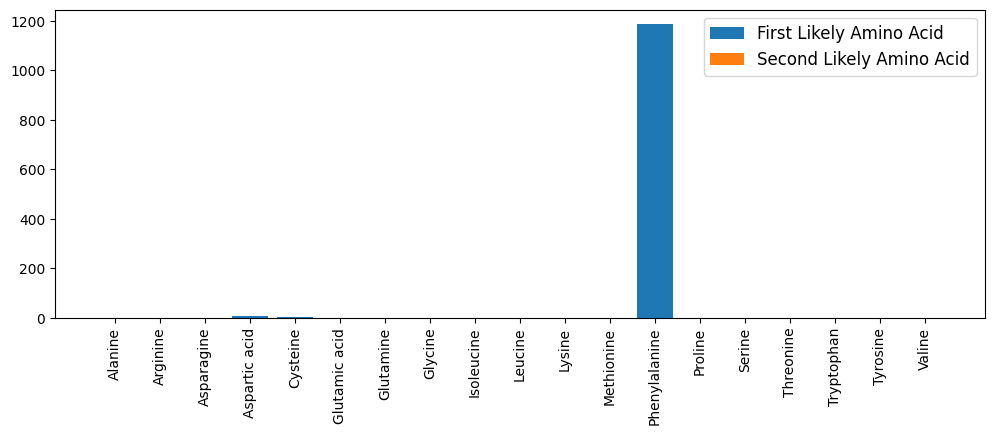

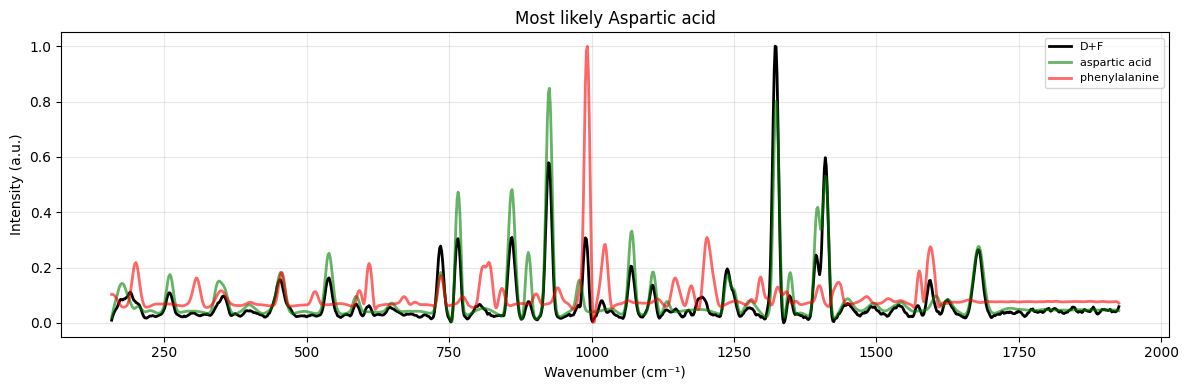

Aspartic acid 0.85797447
Asparagine 0.031562526


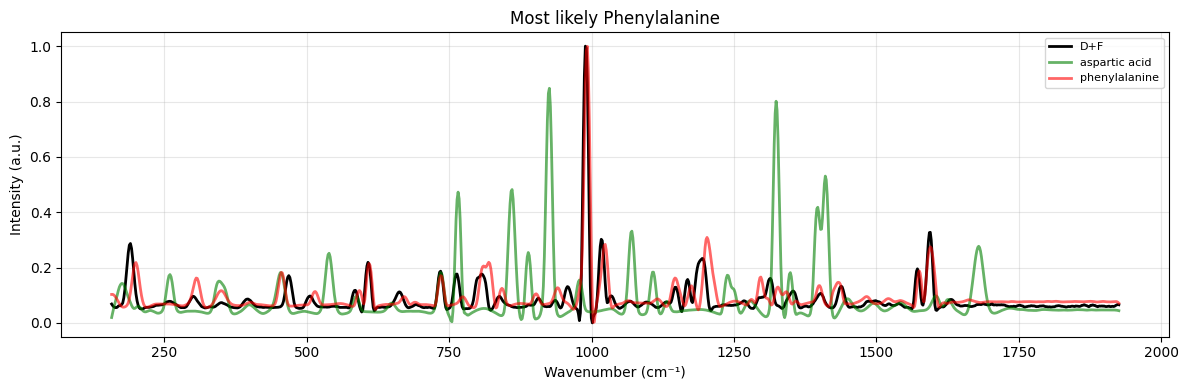

Phenylalanine 0.82510304
Cysteine 0.020784544


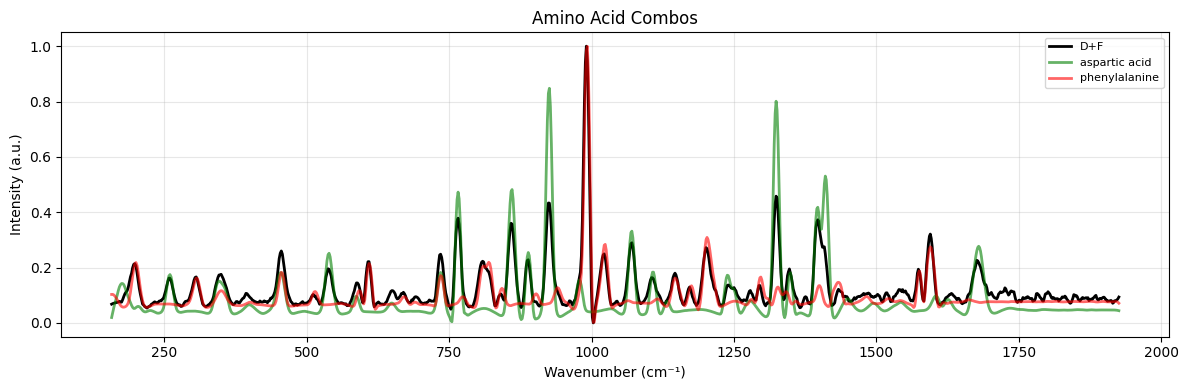

Cysteine 0.46115366
Phenylalanine 0.12028487


In [8]:
name = 'D+F'
snr_threshold = 30
results = process_mixed_amino_acids(name, snr_threshold)

# Convolution between single amino acids v.s. mixture signal 

## A+D

In [10]:
from scipy.optimize import minimize_scalar

def estimate_mixture_weight(fg0, fg1, fg2):
    """
    Estimate optimal mixture weight alpha by minimizing loss between
    computed superposition and measured mixture.

    Args:
        fg0: Mixture spectrum (Spectrum object)
        fg1: First amino acid fingerprint (Spectrum object)
        fg2: Second amino acid fingerprint (Spectrum object)

    Returns:
        alpha: Mixing weight in [0, 1] range
    """
    y0 = fg0.intensities
    y1 = fg1.intensities
    y2 = fg2.intensities

    def loss(alpha):
        y_pred = alpha * y1 + (1 - alpha) * y2
        # Min-max normalization to [0, 1]
        y_pred = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())
        return np.mean(np.abs(y0 - y_pred))  # MAE loss

    result = minimize_scalar(loss, bounds=(0, 1), method='bounded')
    return result.x

In [23]:
def conv_amino_acids(name, snr_threshold=30):
    aa1 = convert_amino_acid(name.split('+')[0], "full")
    cls1 = None
    for key, value in label_names.items():
        if aa1 == value:
            cls1 = key
            break;
    aa2 = convert_amino_acid(name.split('+')[1], 'full')
    cls2 = None
    for key, value in label_names.items():
        if aa2 == value:
            cls2 = key
            break;
    print(f'{name}\n{aa1}({cls1})\t{aa2}({cls2})\n')
    
    # read fingerprints
    fg1 = load_from_npz(Path('./data/monopeptide/') / aa1 / 'fingerprint.npz')[0]
    fg2 = load_from_npz(Path('./data/monopeptide/') / aa2 / 'fingerprint.npz')[0]
    
    # Compute convolution between two fingerprints (same length output)
    # fgc_intensities = np.convolve(fg1.intensities, fg2.intensities, mode='same')
    # fgc_intensities = (fgc_intensities - fgc_intensities.min()) / (fgc_intensities.max() - fgc_intensities.min())
    # fgc = Spectrum(np.stack((fg1.wavelengths, fgc_intensities), axis=1))
    
    
    
    # read combos data
    collection = load_from_npz(Path('./data/combos2/') / name / 'data.npz')
    snr_values = calculate_snr(collection)
    
    idx_data = np.where(snr_values>snr_threshold)[0]
    
    print('Summary:\n')
    print(f'Number of Spectra: {len(collection)}')
    print(f'Number of Noisy Spectra (SNR < {snr_threshold}): {len(collection)-len(idx_data)}')
    print(f'Number of Clean Spectra (SNR >= {snr_threshold}): {len(idx_data)}')
    
    # classify samples
    results = []
    for id0 in idx_data:
        fg0 = collection[id0]
        alpha = estimate_mixture_weight(fg0, fg1, fg2)
        probs = predictor.predict_proba(fg0.intensities)[0]
        predicted_cls_ids = np.argsort(probs)[::-1][:2]
        result = {'id': id0,
                  'snr': snr_values[id0],
                  'probs': probs[predicted_cls_ids],
                  'labels': predicted_cls_ids,
                  'alpha': alpha,
                 }
        results.append(result)
    
    # scenario (both class presents)
    first_amino = np.array([r['labels'][0] for r in results])
    max_p = np.array([r['probs'][0] for r in results])
    filter = np.where(np.logical_and(max_p<0.4, max_p > 0))[0]
    if len(filter) > 0:
        result = [r for r in results if r['id']==954][0]
        id0 = result['id']
        alpha = result['alpha']
        fg0 = collection[id0]
        print(f'alpha={alpha}')
        # Compute superposition (sum) of two fingerprints
        fgc2_intensities = alpha*fg1.intensities + (1-alpha)*fg2.intensities
        fgc2_intensities = (fgc2_intensities - fgc2_intensities.min()) / (fgc2_intensities.max() - fgc2_intensities.min())
        fgc2 = Spectrum(np.stack((fg1.wavelengths, fgc2_intensities), axis=1))
        
        # plot samples
        plot_fingerprints(
            (fg0, f'{name} (measured)'),
            (fgc2, f'{name} (superposition)'),
            (fg1, aa1),
            (fg2, aa2),
            title=f'Amino Acid Combos'
        )
        plot_fingerprints(
            (fg0, f'{name} (measured)'),
            (fgc2, 'superposition'),
            title=f'Amino Acid Combos'
        )
        print(label_names[results[filter[0]]['labels'][0]].capitalize(), results[filter[0]]['probs'][0])
        print(label_names[results[filter[0]]['labels'][1]].capitalize(), results[filter[0]]['probs'][1])
    return results

A+D
alanine(0)	aspartic acid(3)

Summary:

Number of Spectra: 1292
Number of Noisy Spectra (SNR < 50): 588
Number of Clean Spectra (SNR >= 50): 704
alpha=0.45853152984478585


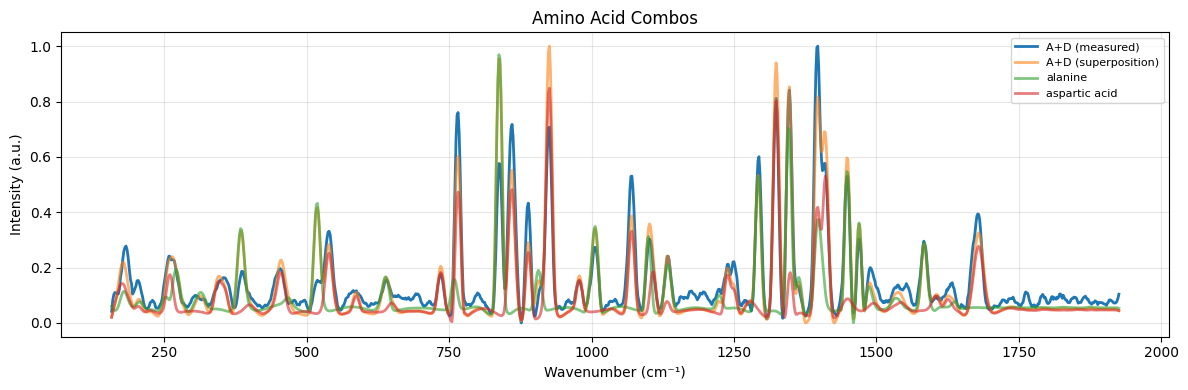

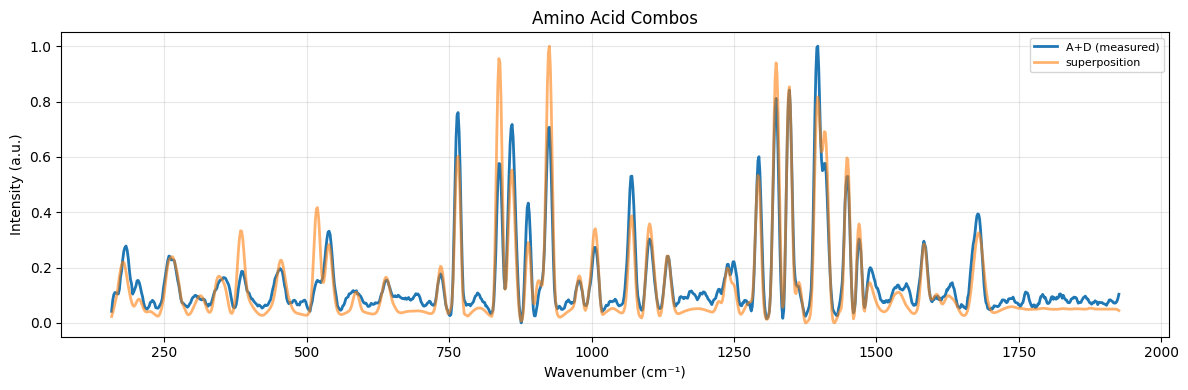

Alanine 0.33826697
Aspartic acid 0.24506934


In [24]:
name = 'A+D'
snr_threshold = 50
result = conv_amino_acids(name, snr_threshold)

(array([ 6.,  5., 10., 12., 13., 14., 13., 18., 16., 21., 16., 15., 10.,
        10., 21., 15., 13.,  9., 14., 13., 11.,  8.,  2.,  7.,  9.,  9.,
         8.,  2.,  0.,  4.]),
 array([3.35640477e-06, 3.33364043e-02, 6.66694522e-02, 1.00002500e-01,
        1.33335548e-01, 1.66668596e-01, 2.00001644e-01, 2.33334692e-01,
        2.66667740e-01, 3.00000788e-01, 3.33333835e-01, 3.66666883e-01,
        3.99999931e-01, 4.33332979e-01, 4.66666027e-01, 4.99999075e-01,
        5.33332123e-01, 5.66665171e-01, 5.99998219e-01, 6.33331267e-01,
        6.66664314e-01, 6.99997362e-01, 7.33330410e-01, 7.66663458e-01,
        7.99996506e-01, 8.33329554e-01, 8.66662602e-01, 8.99995650e-01,
        9.33328698e-01, 9.66661746e-01, 9.99994794e-01]),
 <BarContainer object of 30 artists>)

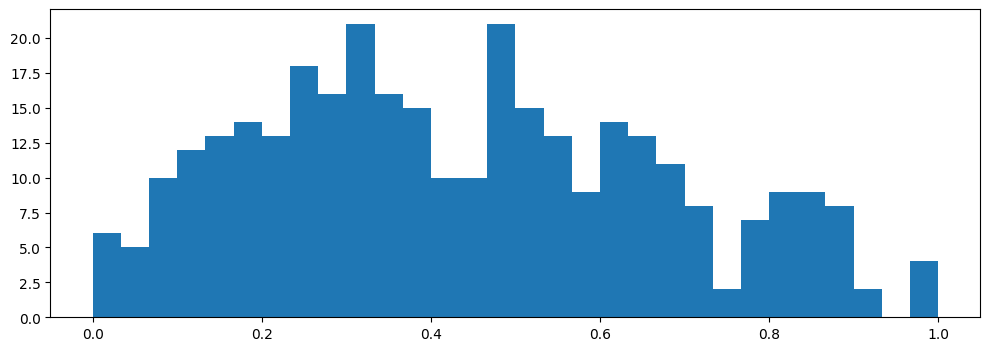

In [94]:
alpha = np.array([r['alpha'] for r in result])
max_p = np.array([r['probs'][0] for r in result])
ids = np.array([r['labels'][0] for r in result])
# print(alpha)
# plt.scatter(1-alpha[ids==12], max_p[ids==12])
plt.hist(alpha, 30)